In [ ]:
import socket
import argparse

temperaturas=[]
leituras = []
quant = 20


HOST = "159.203.79.141"
PORT = 50000
device_id = "43567130870"

# Create a socket
sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)

# Connect to the remote host and port
sock.connect((HOST, PORT))

print("conectado")

# Send a request to the host
sock.send("app\n".encode()[:-1])

# Get the host's response, no more than, say, 1,024 bytes
response_data = sock.recv(1024)

sresponse = response_data.decode("utf-8")
print(sresponse)

if(sresponse == "fail"):
  sock.close()
  exit()

# Send a request to the host
sock.send((device_id+"\n").encode()[:-1])

# Get the host's response, no more than, say, 1,024 bytes
response_data = sock.recv(1024)

sresponse = response_data.decode("utf-8")
print(sresponse)

if(sresponse == "fail"):
  sock.close()
  exit()

for i in range (quant):
  # Get the host's response, no more than, say, 1,024 bytes
  response_data = sock.recv(1024).decode("utf-8")

  print(f"Dado recebido: {response_data}")

  temperaturas.append(float(response_data))
  leituras.append(i+1)

# Terminate
sock.close( )
print("\n")
print("----------------")
print("\n")
print("Temperaturas recebidas:")
print(temperaturas)


conectado
ok
ok
Dado recebido: 24.00
Dado recebido: 24.00
Dado recebido: 24.00
Dado recebido: 24.00
Dado recebido: 11.31
Dado recebido: 11.31
Dado recebido: 37.00
Dado recebido: 52.69
Dado recebido: 52.69
Dado recebido: 65.59
Dado recebido: -18.21
Dado recebido: 2.99
Dado recebido: 21.40
Dado recebido: 21.40
Dado recebido: 39.81
Dado recebido: 56.41
Dado recebido: 74.77
Dado recebido: -16.29
Dado recebido: 1.19
Dado recebido: 26.89


----------------


Temperaturas recebidas:
[24.0, 24.0, 24.0, 24.0, 11.31, 11.31, 37.0, 52.69, 52.69, 65.59, -18.21, 2.99, 21.4, 21.4, 39.81, 56.41, 74.77, -16.29, 1.19, 26.89]


    N° de leituras  Temperaturas
0                1         24.00
1                2         24.00
2                3         24.00
3                4         24.00
4                5         11.31
5                6         11.31
6                7         37.00
7                8         52.69
8                9         52.69
9               10         65.59
10              11        -18.21
11              12          2.99
12              13         21.40
13              14         21.40
14              15         39.81
15              16         56.41
16              17         74.77
17              18        -16.29
18              19          1.19
19              20         26.89


<Axes: xlabel='N° de leituras', ylabel='Temperaturas'>

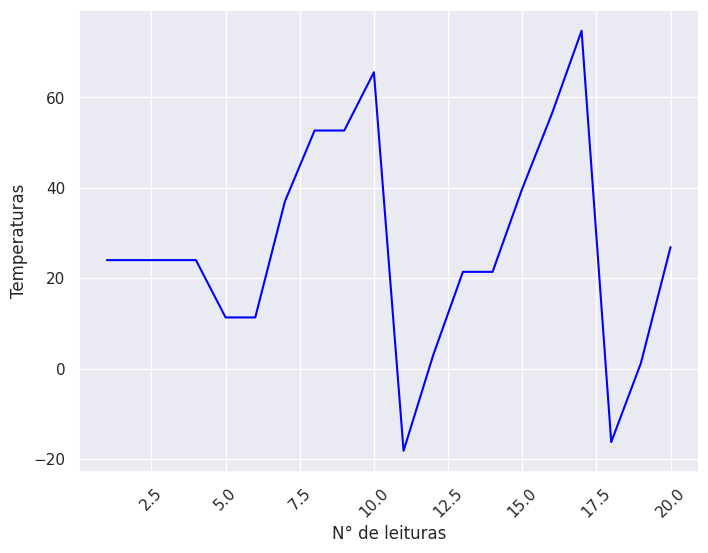

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

#Gráfico Linha

dados = {
    'N° de leituras' : leituras,
    'Temperaturas': temperaturas
}

df = pd.DataFrame(dados)
print(df)
plt.figure(figsize=(8,6))
plt.xticks(rotation=45)
sns.set_theme(style="darkgrid")
sns.lineplot(data=df, x='N° de leituras', y='Temperaturas', color='blue')

    Dia de leitura  Temperaturas
0                1         24.00
1                1         24.00
2                1         24.00
3                1         24.00
4                1         11.31
5                1         11.31
6                1         37.00
7                1         52.69
8                1         52.69
9                1         65.59
10               1        -18.21
11               1          2.99
12               1         21.40
13               1         21.40
14               1         39.81
15               1         56.41
16               1         74.77
17               1        -16.29
18               1          1.19
19               1         26.89


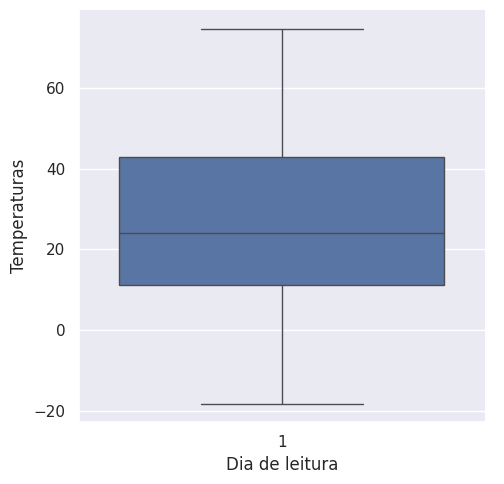

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

#Gráfico Linha

dados = {
    'Dia de leitura' : [1]*quant,
    'Temperaturas': temperaturas
  }

df = pd.DataFrame(dados)
print(df)
sns.catplot(data=df, x="Dia de leitura", y="Temperaturas", kind="box")